Task: Cuisine Combination

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# Load Dataset
df = pd.read_csv("../Dataset .csv")

In [5]:
# Remove missing values
df = df.dropna(subset=["Cuisines"])

# Top cuisine combinations
cuisine_combo = df["Cuisines"].value_counts()

print("Top 10 Cuisine Combinations")
print(cuisine_combo.head(10))

Top 10 Cuisine Combinations
Cuisines
North Indian                      936
North Indian, Chinese             511
Chinese                           354
Fast Food                         354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Name: count, dtype: int64


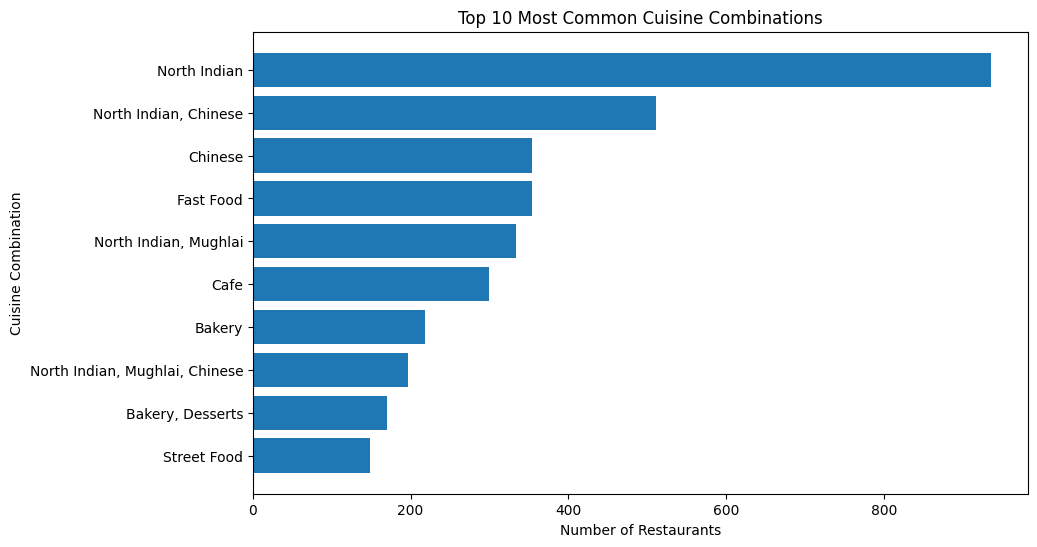

In [6]:
# Bar Chart
top10 = cuisine_combo.head(10)

plt.figure(figsize=(10,6))
plt.barh(top10.index, top10.values)
plt.title("Top 10 Most Common Cuisine Combinations")
plt.xlabel("Number of Restaurants")
plt.ylabel("Cuisine Combination")
plt.gca().invert_yaxis()
plt.show()

In [7]:
# Average Rating
rating_combo = (
    df.groupby("Cuisines")["Aggregate rating"]
      .mean()
      .sort_values(ascending=False)
)

print("\nTop Cuisine Combinations by Average Rating")
print(rating_combo.head(10))


Top Cuisine Combinations by Average Rating
Cuisines
Burger, Bar Food, Steak            4.9
American, Burger, Grill            4.9
American, Caribbean, Seafood       4.9
American, Coffee and Tea           4.9
Mexican, American, Healthy Food    4.9
Italian, Bakery, Continental       4.9
BBQ, Breakfast, Southern           4.9
European, German                   4.9
Hawaiian, Seafood                  4.9
Sunda, Indonesian                  4.9
Name: Aggregate rating, dtype: float64


In [8]:
# Count + Rating
result = df.groupby("Cuisines").agg(
    Restaurant_Count=("Restaurant Name", "count"),
    Average_Rating=("Aggregate rating", "mean")
)

result = result.sort_values(
    by="Restaurant_Count",
    ascending=False
)

print("\nTop 10 Most Common Cuisine Combinations")
print(result.head(10))


Top 10 Most Common Cuisine Combinations
                                Restaurant_Count  Average_Rating
Cuisines                                                        
North Indian                                 936        1.672329
North Indian, Chinese                        511        2.421722
Chinese                                      354        2.042090
Fast Food                                    354        2.118362
North Indian, Mughlai                        334        2.888623
Cafe                                         299        2.890970
Bakery                                       218        1.924312
North Indian, Mughlai, Chinese               197        2.568528
Bakery, Desserts                             170        2.317647
Street Food                                  149        2.161745
